###Build a basic chatbot with Langgraph(GRAPH API)

In [75]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [76]:
class State(TypedDict):
    messages:Annotated[list,add_messages]
graph_builder=StateGraph(State)

In [77]:
graph_builder

In [78]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [79]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
llm=ChatGroq(model="qwen/qwen3.6-27b")

In [80]:
##Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}
    

In [81]:
#creating a state graph
graph_builder=StateGraph(State)
#creating a node
graph_builder.add_node("llmchatbot",chatbot)
#creating a edge
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)
#compile the graph
graph=graph_builder.compile()

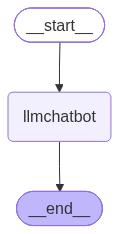

In [82]:
#display of graph
from IPython.display import Image,display 
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [83]:
response=graph.invoke({"messages":"what is ai"})

In [84]:
response["messages"][-1].content

'\n<think>\nHere\'s a thinking process:\n\n1.  **Understand User Input**: The user asked "what is ai". This is a straightforward, fundamental question about Artificial Intelligence.\n\n2.  **Identify Key Components of AI**:\n   - Definition: What does AI stand for? What is it fundamentally?\n   - Core Concept: Machines/computer systems performing tasks that typically require human intelligence.\n   - Key Capabilities/Functions: Learning, reasoning, problem-solving, perception, language understanding, decision-making.\n   - Types/Categories: Narrow/Weak AI vs. General/Strong AI (and sometimes Super AI, though theoretical).\n   - How it Works (Briefly): Machine learning, neural networks, data, algorithms.\n   - Applications/Examples: Voice assistants, recommendation systems, autonomous vehicles, medical diagnosis, etc.\n   - Current State & Limitations: Mostly narrow AI, still lacks true consciousness/understanding, ethical/societal considerations.\n\n3.  **Structure the Response**:\n   

In [85]:
for event in graph.stream({"messages":"hii! how are you?"}):
    for value in event.values():
        print(value["messages"][-1])

content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "hii! how are you?"\n   - Tone: Friendly, casual, greeting\n   - Intent: Social greeting, checking in\n\n2.  **Identify Key Requirements:**\n   - Respond warmly and politely\n   - Acknowledge the greeting\n   - Answer the question ("how are you?")\n   - Keep it conversational and open-ended\n   - Match the casual/friendly tone\n\n3.  **Formulate Response (Mental Draft):**\n   Hi there! I\'m doing well, thank you for asking! 😊 How are you doing today? Is there anything I can help you with or just chat about?\n\n4.  **Refine Response (Self-Correction/Improvement):**\n   - Check tone: Friendly, appropriate\n   - Check content: Answers question, returns greeting, offers help\n   - Keep it concise\n   - Matches user\'s casual style without being unprofessional\n   - All good.\n\n5.  **Final Output Generation:** (matches the refined version)\n   "Hi there! I\'m doing well, thanks for asking! 😊 How

CHATBOT WITH TOOL

In [86]:
 from langchain_tavily import TavilySearch
 tool=TavilySearch(max_results=2)
 tool.invoke("what is langgraph?")

{'query': 'what is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.youtube.com/watch?v=A4p8AOu2rMM',
   'title': 'LangGraph Explained in 4 minutes (LangGraph Tutorial)',
   'content': '❓Topics covered:\nwhat is langgraph\nwhat is langsmith\nwhat is langchain\nlangchain tutorial\nlanggraph tutorial\nlangsmith tutorial\nlanggraph explained\nlangchain explained\nlangsmith explained\n\n⏱️ Timestamps:\n0:00 What is LangGraph\n0:26 Why Is LangGraph Popular?\n1:13 Without LangGraph\n1:51 With LangGraph\n3:15 When NOT to use LangGraph\n\n🎶beats:  @massobeats  \nhoneyjam: \n\n#programming #ai',
   'score': 0.02382871353511696,
   'raw_content': None,
   'id': 'de9664-00'},
  {'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provid

In [87]:
def multiply(a:int,b:int)->int:
    """multiply a and b
    args:a(int) first int
    b(int) seconf=d int
    return integer value"""
    return a*b


In [88]:
tools=[tool,multiply]

In [89]:
llm_with_tools=llm.bind_tools(tools)

In [90]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, client=<groq.resources.chat.completions.Completions object at 0x00000261F1B743E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000261F1D85480>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'str

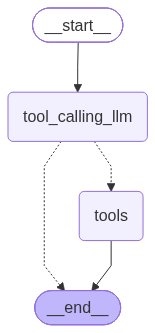

In [91]:
from langgraph.typing import StateT_contra
#stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode 
from langgraph.prebuilt import tools_condition
 #node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}
#graph
builder=StateGraph(State)
#addnode
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))
#add edge
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition
    #If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
)
builder.add_edge("tools",END)
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [92]:
response=graph.invoke({"messages":"what is recent ai news?"})

In [93]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/2026/08/31/bailey-frontier-ai-financial-stability-risk.html", "title": "Bank of England chief warns new AI models threaten global financial stability", "content": "\\"Recent developments have also highlighted to me that many jurisdictions do not have the protocols in place to manage the development, release, and deployment of advanced frontier AI models, heightening risks for the financial sector and beyond,\\" he added.\\n\\nThe letter adds to a growing chorus of warnings about the dangers associated with advanced AI and comes shortly after a series of high-profile incidents in which flagship models tested by Anthropic and OpenAI breached testing safeguards.\\n\\nFinancial institutions and technology providers will need to improve vulnerability management, response and recovery capabilities — \\"and prepare for more severe scenarios involving simultaneous d

In [94]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is recent ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (tawmfxqgg)
 Call ID: tawmfxqgg
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/2026/08/31/bailey-frontier-ai-financial-stability-risk.html", "title": "Bank of England chief warns new AI models threaten global financial stability", "content": "\"Recent developments have also highlighted to me that many jurisdictions do not have the protocols in place to manage the development, release, and deployment of advanced frontier AI models, heightening risks for the financial sector and beyond,\" he added.\n

In [99]:
response=graph.invoke({"messages":"multiply 2 by 4 and multiply 5 by 10 "})
for n in response["messages"]:
    n.pretty_print()

================================ Human Message =================================

multiply 2 by 4 and multiply 5 by 10 
================================== Ai Message ==================================
Tool Calls:
  multiply (yzect5e1k)
 Call ID: yzect5e1k
  Args:
    a: 2
    b: 4
================================= Tool Message =================================
Name: multiply

8


REACT AGENT ARCHITECTURE

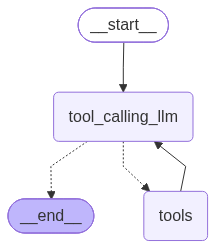

In [100]:
from langgraph.typing import StateT_contra
#stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode 
from langgraph.prebuilt import tools_condition
 #node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}
#graph
builder=StateGraph(State)
#addnode
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))
#add edge
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition
    #If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
)
builder.add_edge("tools","tool_calling_llm")
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))    

In [101]:
response=graph.invoke({"messages":"multiply 2 by 4 and multiply 5 by 10 "})
for n in response["messages"]:
    n.pretty_print()

================================ Human Message =================================

multiply 2 by 4 and multiply 5 by 10 
================================== Ai Message ==================================
Tool Calls:
  multiply (j9q7a8yvc)
 Call ID: j9q7a8yvc
  Args:
    a: 2
    b: 4
================================= Tool Message =================================
Name: multiply

8
================================== Ai Message ==================================
Tool Calls:
  multiply (42gyj1nhn)
 Call ID: 42gyj1nhn
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: multiply

50
================================== Ai Message ==================================

2 multiplied by 4 is 8, and 5 multiplied by 10 is 50.


ADDING MEMORY IN AGENTIC GRAPH

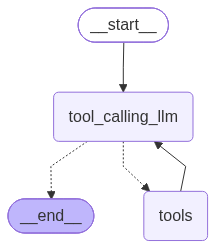

In [103]:
from langgraph.typing import StateT_contra
#stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode 
from langgraph.prebuilt import tools_condition

#MEMORY
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
 #node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}
#graph
builder=StateGraph(State)
#addnode
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))
#add edge
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition
    #If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
)
builder.add_edge("tools","tool_calling_llm")
graph=builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))    

In [105]:
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":"hi my name is harsha"},config=config)
response

{'messages': [HumanMessage(content='hi my name is harsha', additional_kwargs={}, response_metadata={}, id='845c3b28-2a09-4827-91f9-3910c16d56bb'),
  AIMessage(content='Hello Harsha! Nice to meet you. How can I help you today?', additional_kwargs={'reasoning_content': 'Here\'s a thinking process:\n\n1.  **Analyze User Input:** The user says "hi my name is harsha".\n2.  **Identify Intent:** The user is greeting me and introducing themselves.\n3.  **Determine Response:** I should acknowledge the greeting, use their name, and offer assistance in a friendly manner.\n4.  **Check Tools:** No tools are needed for this simple greeting/introduction.\n5.  **Formulate Response:** "Hello Harsha! Nice to meet you. How can I help you today?" (Keep it polite, concise, and open-ended for further interaction.)✅\n'}, response_metadata={'token_usage': {'completion_tokens': 152, 'prompt_tokens': 1914, 'total_tokens': 2066, 'completion_time': 0.29747794, 'completion_tokens_details': {'reasoning_tokens': 133

In [107]:
response["messages"][-1].content

'Hello Harsha! Nice to meet you. How can I help you today?'

In [109]:
response=graph.invoke({"messages":"hey what is my name?"},config=config)
response["messages"][-1].content

'Your name is Harsha! How can I assist you today?'

Streaming

Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

values: This streams the full state of the graph after each node is called.

updates: This streams updates to the state of the graph after each node is called.

In [110]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()


In [111]:
def superbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

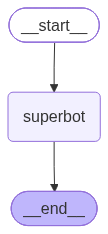

In [112]:
graph=StateGraph(State)
graph.add_node("superbot",superbot)
graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)
graph_builder=graph.compile(checkpointer=memory)
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [116]:
config={"configurable":{"thread_id":"1"}}
response=graph_builder.invoke({"messages":"hi my name is harsha and i like movies"},config=config)
response

{'messages': [HumanMessage(content='hi my name is harsha and i like movies', additional_kwargs={}, response_metadata={}, id='b7057634-1176-449f-abb4-a2dd05bf5339'),
  AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Harsha\n   - Interest: Movies\n   - Greeting: "hi"\n\n2.  **Identify Key Elements:**\n   - Personal greeting needed\n   - Acknowledge name\n   - Acknowledge interest in movies\n   - Keep it friendly and open-ended to encourage conversation\n\n3.  **Determine Response Goals:**\n   - Welcome Harsha\n   - Show enthusiasm about their interest in movies\n   - Ask follow-up questions to engage them\n   - Keep tone warm and conversational\n\n4.  **Draft Response (Mental Refinement):**\n   Hi Harsha! Nice to meet you. I love that you\'re into movies—there\'s so much to explore out there. What kind of movies do you usually enjoy? Any favorite genres, directors, or recent films that really stood out to you? I\'d be happy to recommen

In [117]:
config={"configurable":{"thread_id":"3"}}
for chunk in graph_builder.stream({"messages":"hi my name is harsha and i like movies"},config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "hi my name is harsha and i like movies"\n   - Key information: Name = Harsha, Interest = Movies\n   - Tone: Casual, friendly introduction\n\n2.  **Identify Goal:**\n   - Acknowledge the introduction\n   - Respond warmly and personally\n   - Engage with their interest (movies)\n   - Ask a follow-up question to keep the conversation going\n\n3.  **Formulate Response (Mental Draft):**\n   Hi Harsha! Nice to meet you. I love that you enjoy movies—there\'s so much variety out there. What kind of movies are you into? Any favorites or genres you can\'t get enough of?\n\n4.  **Refine Response (Check against best practices):**\n   - Friendly and personalized: Uses their name, acknowledges their interest\n   - Open-ended question: Encourages conversation\n   - Concise and natural: Matches their casual tone\n   - No overcomplication or unnecessary info\n\n   Looks 

In [118]:
config={"configurable":{"thread_id":"3"}}
for chunk in graph_builder.stream({"messages":"hi my name is harsha and i like movies"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='hi my name is harsha and i like movies', additional_kwargs={}, response_metadata={}, id='4650ede9-d2fe-4bf6-aae1-a8a986d54c70'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "hi my name is harsha and i like movies"\n   - Key information: Name = Harsha, Interest = Movies\n   - Tone: Casual, friendly introduction\n\n2.  **Identify Goal:**\n   - Acknowledge the introduction\n   - Respond warmly and personally\n   - Engage with their interest (movies)\n   - Ask a follow-up question to keep the conversation going\n\n3.  **Formulate Response (Mental Draft):**\n   Hi Harsha! Nice to meet you. I love that you enjoy movies—there\'s so much variety out there. What kind of movies are you into? Any favorites or genres you can\'t get enough of?\n\n4.  **Refine Response (Check against best practices):**\n   - Friendly and personalized: Uses their name, acknowledges their interest\n   - Open-ended questio

In [119]:
config={"configurable":{"thread_id":"4"}}
for chunk in graph_builder.stream({"messages":"i also like webseries"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='i also like webseries', additional_kwargs={}, response_metadata={}, id='ffbddf68-f6b5-47de-bdcb-808967b60f40')]}
{'messages': [HumanMessage(content='i also like webseries', additional_kwargs={}, response_metadata={}, id='ffbddf68-f6b5-47de-bdcb-808967b60f40'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "i also like webseries"\n   - This is a continuation of a conversation (though I don\'t have the prior context, I should acknowledge it naturally).\n   - Key interest: Web series (streaming shows, episodic content, likely on platforms like Netflix, Amazon Prime, Hulu, Disney+, etc.)\n\n2.  **Identify Key Needs/Opportunities:**\n   - Acknowledge their interest positively\n   - Ask clarifying questions to understand preferences (genre, platform, tone, language, etc.)\n   - Offer to recommend based on their tastes\n   - Keep it conversational and open-ended\n\n3.  **Formulate Response Strategy